In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize

run_name = "OptimalCopulaGCS100"
cskew = .0
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = r'C:\dev\MLCopula\data\weights'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = gp_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()

In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize, forest_minimize, gbrt_minimize
from skopt.space import Real

run_name = "OptimalCopulaGCS90gbt20y"
cskew = 0.9
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = r'C:\dev\MLCopula\data\weights'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(240):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    #res = forest_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)
    res = gbrt_minimize(error_func, [(0.0, 1.0)], base_estimator="GP", n_calls=15, x0=prev_x)
    

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()

In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize, forest_minimize, gbrt_minimize
from skopt.space import Real

run_name = "OptimalCopulaGCS100gbt"
cskew = 0.0
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = r'C:\dev\MLCopula\data\weights'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    #res = forest_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)
    res = gbrt_minimize(error_func, [(0.0, 1.0)], base_estimator="GP", n_calls=15, x0=prev_x)
    

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()

20Y - GBRT minimise

{'SP500_Hedged20y-995': 17.521166666666666}
Market stats 20251231-1Y, non nones count: 98208, needs 98208


c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 3928320, needs 3928320
-----> total error: 0.025683221246682594
Market stats 20251231-1Y, non nones count: 98208, needs 98208
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 3928320, needs 3928320
-----> total error: 0.017122147497788405
Market stats 20251231-1Y, non nones count: 98208, needs 98208
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 3928320, needs 3928320
-----> total error: 0.017122147497788405
Market stats 20251231-1Y, non nones count: 98208, needs 98208
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004032258064516129, max:0.9999
Simulation stats, non

c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004016064257028112, max:0.9999
Simulation stats, non nones count: 3944160, needs 3944160
-----> total error: 0.029107650746240277
Market stats 20251201-1Y, non nones count: 98604, needs 98604
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004016064257028112, max:0.9999
Simulation stats, non nones count: 3944160, needs 3944160
-----> total error: 0.016551409247862112
Market stats 20251101-1Y, non nones count: 98208, needs 98208
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 3928320, needs 3928320
-----> total error: 0.005707382499262802
Market stats 20251101-1Y, non nones count: 98208, needs 98208
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.004032258064516129, max:0.9999
Simulation stats, non

...

=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.005813953488372093, max:0.9999
Simulation stats, non nones count: 3950496, needs 3950496
-----> total error: 0.04451758349424983
Market stats 20060912-1Y, non nones count: 68112, needs 68112
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.005813953488372093, max:0.9999
Simulation stats, non nones count: 3950496, needs 3950496
-----> total error: 0.027966174246387716
Market stats 20060912-1Y, non nones count: 68112, needs 68112
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
=> min:0.005813953488372093, max:0.9999
Simulation stats, non nones count: 3950496, needs 3950496
-----> total error: 0.027966174246387716
Market stats 20060912-1Y, non nones count: 68112, needs 68112
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.005813953488372093, max:0.9999
Simulation stats, non 

c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.006622516556291391, max:0.9999
Simulation stats, non nones count: 3946536, needs 3946536
-----> total error: 0.04622979824402867
Market stats 20060813-1Y, non nones count: 59796, needs 59796
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.006622516556291391, max:0.9999
Simulation stats, non nones count: 3946536, needs 3946536
-----> total error: 0.03196134199587167
Market stats 20060813-1Y, non nones count: 59796, needs 59796
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.006622516556291391, max:0.9999
Simulation stats, non nones count: 3946536, needs 3946536
-----> total error: 0.021117315247272353
Market stats 20060813-1Y, non nones count: 59796, needs 59796
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.006622516556291391, max:0.9999
Simulation stats, non n

c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.007633587786259542, max:0.9999
Simulation stats, non nones count: 3942576, needs 3942576
-----> total error: 0.01883436224756722
Market stats 20060714-1Y, non nones count: 51876, needs 51876
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.007633587786259542, max:0.9999
Simulation stats, non nones count: 3942576, needs 3942576
-----> total error: 0.013697717998230712
Market stats 20060714-1Y, non nones count: 51876, needs 51876
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.007633587786259542, max:0.9999
Simulation stats, non nones count: 3942576, needs 3942576
-----> total error: 0.0028536912496313883
Market stats 20060614-1Y, non nones count: 43560, needs 43560
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3959604, needs 3959604
=> min:0.00909090909090909, max:0.9999
Simulation stats, non 

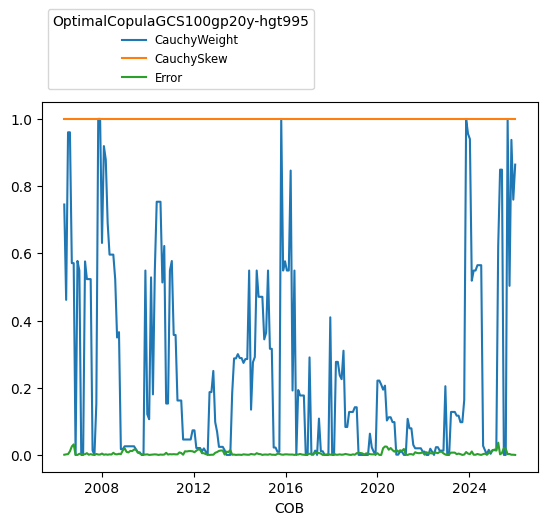

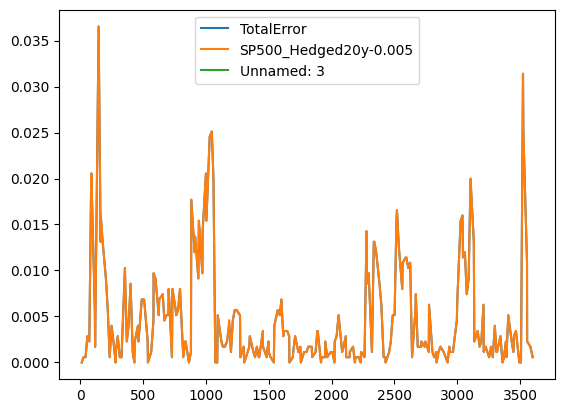

In [33]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize, forest_minimize, gbrt_minimize
from skopt.space import Real

run_name = "OptimalCopulaGCS100gp20y-hgt995"
method= "Bayesian optimisation using Gaussian Processes"
cskew = 1.0
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_Hedged20y']
measures= [0.005]
store_errors = True

output_path_part = r'C:\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=20, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(240):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    #res = forest_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)

    if method == "Sequential optimisation using gradient boosted trees":
       res = gbrt_minimize(error_func, [(0.0, 1.0)], base_estimator="GP", n_calls=13, x0=prev_x)
    elif method == "Bayesian optimisation using Gaussian Processes":
        res = gp_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)
    elif method == "Sequential optimisation using decision trees":
        res = forest_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()